# Cadastral Exploration

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

shapefile_path = r'D:\WRI\Field Boundaries\Uruguay Data\paisrural_shp\PaisRural.shp'
data = gpd.read_file(shapefile_path)

# Plot field size hist
filtered_data = data['AREAHA'].dropna()
filtered_data = filtered_data[(filtered_data >= 0) & (filtered_data <= 20)]

# Plot the histogram of the AREAHA column
plt.figure(figsize=(10, 6))
plt.hist(filtered_data, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of AREAHA (0 to 20 hectares)', fontsize=16)
plt.xlabel('AREAHA', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()


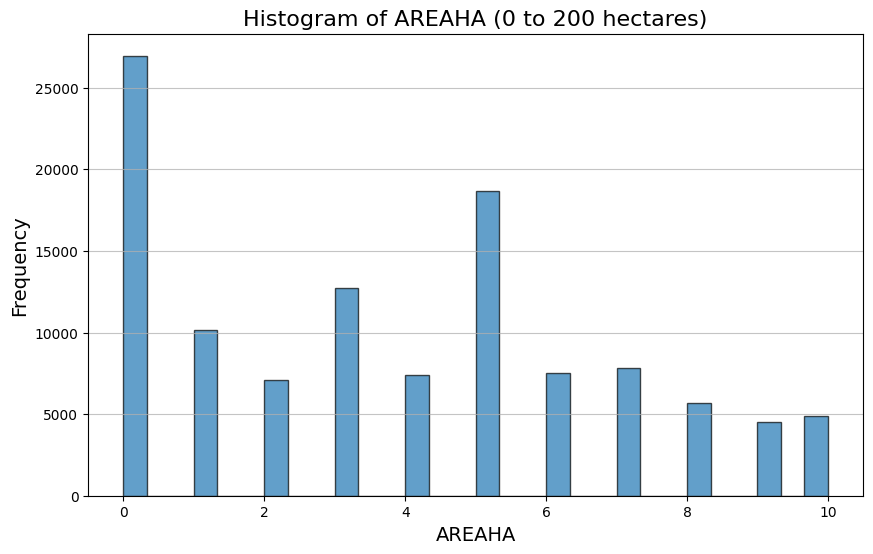

In [7]:
# Plot field size hist
filtered_data = data['AREAHA'].dropna()
filtered_data = filtered_data[(filtered_data >= 0) & (filtered_data <= 10)]

# Plot the histogram of the AREAHA column
plt.figure(figsize=(10, 6))
plt.hist(filtered_data, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of AREAHA (0 to 200 hectares)', fontsize=16)
plt.xlabel('AREAHA', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.75)
plt.show()


# Divide Geometries of the Field

- Fields between 0-5 hectares, generate a 10 meter by 10 meter grid within each one. Label each grid with a fieldID of the field. 
Convert to centroids. Drop all centroids that fall outside the field geometry.
- 5-20 Hectares: 50m x 50m grid
- 20-100 Hectares: 100m x 100m grid
- 100+ Hectares: 200m x 200m grid

Filter centroids so only max 10 per field, maximize difference between 10 centroids using lat, lon


In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, Polygon
from shapely.validation import explain_validity
from scipy.spatial import distance
import matplotlib.pyplot as plt

def generate_grid(polygon, cell_size):
    """
    Generate a grid of polygons within a bounding box of a given geometry.
    """
    minx, miny, maxx, maxy = polygon.bounds
    x_coords = np.arange(minx, maxx, cell_size)
    y_coords = np.arange(miny, maxy, cell_size)
    grid = []
    for x in x_coords:
        for y in y_coords:
            cell = Polygon([(x, y), (x + cell_size, y), (x + cell_size, y + cell_size), (x, y + cell_size)])
            if cell.is_valid:
                grid.append(cell)
    return grid

def process_fields(data, area_min, area_max, cell_size):
    """
    Process fields within a specified area range, generate grids, and filter centroids.
    """
    filtered_fields = data[(data['AREAHA'] >= area_min) & (data['AREAHA'] <= area_max)]
    centroids = []
    for _, row in filtered_fields.iterrows():
        if not row.geometry.is_valid:
            print("Invalid polygon:", explain_validity(row.geometry))
            continue

        grid = generate_grid(row.geometry, cell_size)

        # Debug: Plot polygon and grid
        plot_polygon_and_grid(row.geometry, grid)

        # Use `intersects` to include centroids on the boundary
        grid_centroids = [cell.centroid for cell in grid if row.geometry.intersects(cell.centroid)]

        if not grid_centroids:
            print(f"No centroids found inside or on the boundary of polygon with fieldID {row['fieldID']}")

        field_centroids = maximize_distance(grid_centroids, max_points=10)
        for centroid in field_centroids:
            centroids.append({'fieldID': row['fieldID'], 'geometry': Point(centroid.x, centroid.y)})
    return centroids

def maximize_distance(centroids, max_points):
    """
    Filter centroids to a maximum number by maximizing the distance between them.
    """
    if len(centroids) <= max_points:
        return centroids

    points = np.array([(centroid.x, centroid.y) for centroid in centroids])
    selected_indices = [0]  # Start with the first point

    while len(selected_indices) < max_points:
        remaining_indices = list(set(range(len(points))) - set(selected_indices))
        dist_matrix = distance.cdist(points[selected_indices], points[remaining_indices])
        max_dist_idx = remaining_indices[np.argmax(np.min(dist_matrix, axis=0))]
        selected_indices.append(max_dist_idx)

    return [centroids[i] for i in selected_indices]

def plot_polygon_and_grid(polygon, grid):
    """
    Plot the polygon and grid for debugging.
    """
    plt.figure(figsize=(8, 8))
    x, y = polygon.exterior.xy
    plt.plot(x, y, label="Polygon", color="blue")

    for cell in grid:
        x, y = cell.exterior.xy
        plt.plot(x, y, color="lightgrey", linestyle="--")

    plt.title("Polygon and Grid")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

# Load the shapefile
shapefile_path = r"C:\Users\grupp\Desktop\Urugay NDVI\Uruguay_PaisRural_pt1_extract.shp"
data = gpd.read_file(shapefile_path)

# Add a unique ID for each polygon
data['fieldID'] = range(1, len(data) + 1)

# Define area ranges and grid sizes
area_grid_sizes = [
    (0, 5, 10),      # For fields between 0-5 hectares: 10m x 10m grid
    (5, 20, 50),     # For fields between 5-20 hectares: 50m x 50m grid
    (20, 100, 100),  # For fields between 20-100 hectares: 100m x 100m grid
    (100, float('inf'), 200)  # For fields larger than 100 hectares: 200m x 200m grid
]

# Process fields for each range and combine results
all_centroids = []
for area_min, area_max, cell_size in area_grid_sizes:
    centroids = process_fields(data, area_min, area_max, cell_size)
    all_centroids.extend(centroids)

# Create a GeoDataFrame for centroids
centroid_gdf = gpd.GeoDataFrame(all_centroids, columns=['fieldID', 'geometry'], crs=data.crs)

# Save results
centroid_gdf.to_file(r"C:\Users\grupp\Desktop\Urugay NDVI\Uruguay_PaisRural_pt1_extract_centroids_filtered.shp")


In [1]:
import pandas as pd

# Define file path
file_path = r"D:\WRI\Field Boundaries\RFP ground truth consultancy\WRI TfT consultancy test locations.xlsx"

# Load the Excel file
df = pd.read_excel(file_path)

# Ensure necessary columns exist
required_columns = {'COUNTRY', 'NAME_1', 'NAME_2'}
if not required_columns.issubset(df.columns):
    raise ValueError(f"Missing required columns. Found columns: {df.columns}")

# Group by COUNTRY and NAME_1, aggregating NAME_2 values
grouped = df.groupby(['COUNTRY', 'NAME_1'])['NAME_2'].apply(list).reset_index()

# Filter groups where NAME_2 has duplicates
duplicates = grouped[grouped['NAME_2'].apply(lambda x: len(x) > 1)]

# Print the results
if not duplicates.empty:
    print("NAME_2 values that share the same NAME_1 and COUNTRY:")
    for _, row in duplicates.iterrows():
        print(f"COUNTRY: {row['COUNTRY']}, NAME_1: {row['NAME_1']}, NAME_2: {', '.join(row['NAME_2'])}")
else:
    print("No duplicates found.")


NAME_2 values that share the same NAME_1 and COUNTRY:
COUNTRY: Argentina, NAME_1: Chaco, NAME_2: Fray Justo Santa María de Oro, Mayor Luis J. Fontana
COUNTRY: Argentina, NAME_1: Corrientes, NAME_2: Bella Vista, Berón de Astrada, Concepción, General Paz, Itatí, Saladas, San Miguel, San Roque
COUNTRY: Argentina, NAME_1: Formosa, NAME_2: Formosa, Pilagás, Pilcomayo, Pirané
COUNTRY: Argentina, NAME_1: Santa Fe, NAME_2: Nueve de Julio, Vera
COUNTRY: Brazil, NAME_1: Bahia, NAME_2: Muquém do São Francisco, Santana, Serra Dourada
COUNTRY: Brazil, NAME_1: Goiás, NAME_2: Adelândia, Americano do Brasil, Anicuns, Campinorte, Cristalina, Heitoraí, Itaguaru, Itapuranga, Jaraguá, Luziânia, Santa Bárbara de Goiás, Trindade, Uruaçu, Uruana
COUNTRY: Brazil, NAME_1: Mato Grosso, NAME_2: Acorizal, Alta Floresta, Araputanga, Barra do Bugres, Cáceres, Carlinda, Chapada dos Guimarães, Comodoro, Figueirópolis D'Oeste, Guarantã do Norte, Indiavaí, Jauru, Juína, Nova Guarita, Novo Mundo, Poconé, Porto Esperidiã

In [2]:
import pandas as pd

# Define file path
file_path = r"D:\WRI\Field Boundaries\RFP ground truth consultancy\WRI TfT consultancy test locations.xlsx"

# Load the Excel file
df = pd.read_excel(file_path)

# Ensure necessary columns exist
required_columns = {'COUNTRY', 'NAME_1', 'NAME_2'}
if not required_columns.issubset(df.columns):
    raise ValueError(f"Missing required columns. Found columns: {df.columns}")

# Group by COUNTRY and NAME_1, aggregating NAME_2 values
grouped = df.groupby(['COUNTRY', 'NAME_1'])['NAME_2'].apply(list).reset_index()

# Filter groups where NAME_2 has duplicates
duplicates = grouped[grouped['NAME_2'].apply(lambda x: len(x) > 1)]

# Print results without column names
if not duplicates.empty:
    for _, row in duplicates.iterrows():
        print(f"{row['COUNTRY']}, {row['NAME_1']}, {', '.join(row['NAME_2'])}")


Argentina, Chaco, Fray Justo Santa María de Oro, Mayor Luis J. Fontana
Argentina, Corrientes, Bella Vista, Berón de Astrada, Concepción, General Paz, Itatí, Saladas, San Miguel, San Roque
Argentina, Formosa, Formosa, Pilagás, Pilcomayo, Pirané
Argentina, Santa Fe, Nueve de Julio, Vera
Brazil, Bahia, Muquém do São Francisco, Santana, Serra Dourada
Brazil, Goiás, Adelândia, Americano do Brasil, Anicuns, Campinorte, Cristalina, Heitoraí, Itaguaru, Itapuranga, Jaraguá, Luziânia, Santa Bárbara de Goiás, Trindade, Uruaçu, Uruana
Brazil, Mato Grosso, Acorizal, Alta Floresta, Araputanga, Barra do Bugres, Cáceres, Carlinda, Chapada dos Guimarães, Comodoro, Figueirópolis D'Oeste, Guarantã do Norte, Indiavaí, Jauru, Juína, Nova Guarita, Novo Mundo, Poconé, Porto Esperidião, Rosário Oeste, São José dos Quatro Marcos, Tangará da Serra
Brazil, Mato Grosso do Sul, Bela Vista, Cassilândia, Paranaíba, Porto Murtinho
Brazil, Minas Gerais, Caldas, Campestre, Campina Verde, Capitão Enéas, Curvelo, Francis

In [3]:
import pandas as pd

# Define file path
file_path = r"D:\WRI\Field Boundaries\RFP ground truth consultancy\WRI TfT consultancy test locations.xlsx"

# Load the Excel file
df = pd.read_excel(file_path)

# Ensure necessary columns exist
required_columns = {'COUNTRY', 'NAME_1', 'NAME_2'}
if not required_columns.issubset(df.columns):
    raise ValueError(f"Missing required columns. Found columns: {df.columns}")

# Group by COUNTRY and NAME_1, aggregating NAME_2 values
grouped = df.groupby(['COUNTRY', 'NAME_1'])['NAME_2'].apply(list).reset_index()

# Filter groups where NAME_2 has duplicates
duplicates = grouped[grouped['NAME_2'].apply(lambda x: len(x) > 1)]

# Print results in "County, State: District" format
if not duplicates.empty:
    for _, row in duplicates.iterrows():
        districts = ', '.join(row['NAME_2'])
        print(f"{row['NAME_1']}, {row['COUNTRY']}: {districts}")


Chaco, Argentina: Fray Justo Santa María de Oro, Mayor Luis J. Fontana
Corrientes, Argentina: Bella Vista, Berón de Astrada, Concepción, General Paz, Itatí, Saladas, San Miguel, San Roque
Formosa, Argentina: Formosa, Pilagás, Pilcomayo, Pirané
Santa Fe, Argentina: Nueve de Julio, Vera
Bahia, Brazil: Muquém do São Francisco, Santana, Serra Dourada
Goiás, Brazil: Adelândia, Americano do Brasil, Anicuns, Campinorte, Cristalina, Heitoraí, Itaguaru, Itapuranga, Jaraguá, Luziânia, Santa Bárbara de Goiás, Trindade, Uruaçu, Uruana
Mato Grosso, Brazil: Acorizal, Alta Floresta, Araputanga, Barra do Bugres, Cáceres, Carlinda, Chapada dos Guimarães, Comodoro, Figueirópolis D'Oeste, Guarantã do Norte, Indiavaí, Jauru, Juína, Nova Guarita, Novo Mundo, Poconé, Porto Esperidião, Rosário Oeste, São José dos Quatro Marcos, Tangará da Serra
Mato Grosso do Sul, Brazil: Bela Vista, Cassilândia, Paranaíba, Porto Murtinho
Minas Gerais, Brazil: Caldas, Campestre, Campina Verde, Capitão Enéas, Curvelo, Francis